### Dataset과 DataLoader
- 데이터 샘플을 처리하는 코드는 지저분하고 유지보수가 어려울 수 있음
- 더 나은 가독성과 모듈성을 위해 데이터셋 코드를 모델 학습 코드로부터 분리하는 것이 이상적

__데이터셋 불러오기__
- FasionMNIST 데이터를 불러오기
    - 해당 데이터는 Zalando의 기사 이미지 데이터셋으로 60,000개의 학습 예제와 10,000개의 테스트 예제로 이루어져 있음. 

In [4]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data", # 학습이 저장되는 경로
    train=True, # 학습용 또는 테스트용 데이터셋 여부를 지정
    download=True, # root에 데이터가 없을 경우 인터넷에서 다운로드
    transform=ToTensor(), # 특징과 정답 변형을 지정
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

__Dataset을 순회하고 시각화하기__
- `Dataset`에 리스트처럼 직접 접근할 수 있음
- `training_data[index]`, `matplotlib`을 사용하여 학습 데이터의 일부를 시각화

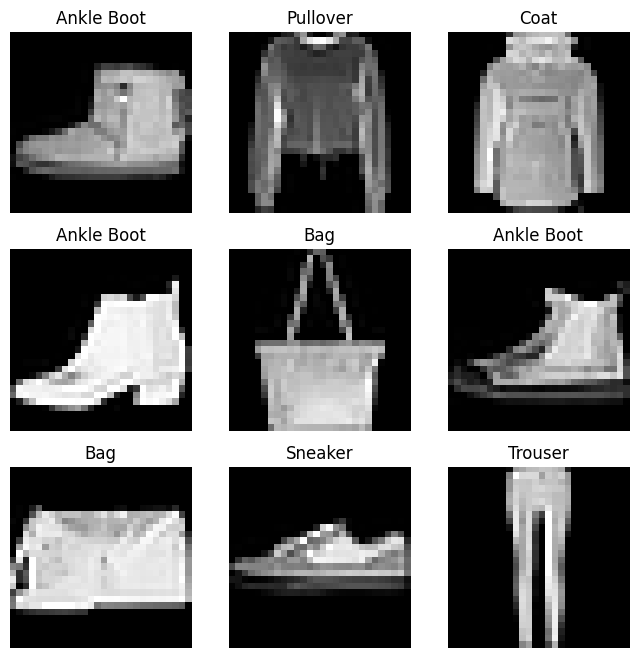

In [26]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8)) # 시각화할 그림의 크기 설정
cols, rows = 3, 3 # 3x3 격자 형태로 이미지 배치
for i in range(1, cols * rows + 1): # 9개의 샘플을 무작위로 선택하여 시각화
    sample_idx = torch.randint(len(training_data), size=(1,)).item() # 무작위 인덱스 생성
    img, label = training_data[sample_idx] # 해당 인덱스의 이미지와 레이블 가져오기
    figure.add_subplot(rows, cols, i) # 서브플롯 추가
    plt.title(labels_map[label]) # 레이블에 해당하는 타이틀 설정 
    plt.axis("off") # 축 숨기기
    plt.imshow(img.squeeze(), cmap="grey") # 이미지 표시
plt.show() # 이미지 출력

__파일에서 사용자 정의 데이터셋 만들기__
- 사용자 정의 Dataset 클래스는 반드시 3개 함수를 구현해야 함
    - `__init__`, `__len__`, `__getitem__`

In [27]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset): # 사용자 정의 데이터셋 클래스
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None): # 초기화 메서드
        self.img_labels = pd.read_csv(annotations_file, names=['file_name', 'label']) # 주석 파일 읽기
        self.img_dir = img_dir # 이미지 디렉토리 경로 설정
        self.transform = transform # 특징 변환 설정
        self.target_transform = target_transform # 정답 변환 설정
        
    def __len__(self): # 데이터셋의 크기 반환
        return len(self.img_labels) 
    
    def __getitem__(self, idx): # 인덱스에 해당하는 샘플 반환
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0]) # 이미지 경로 생성
        image = read_image(img_path) # 이미지 읽기
        label = self.img_labels.iloc[idx, 1] # 레이블 가져오기
        if self.transform: 
            image = self.transform(image) # 특징 변환 적용
        if self.target_transform:
            label = self.target_transform(label) # 정답 변환 적용
        return image, label

__`__init__`__ 
- `__init__` 함수는 Dataset 객체가 생성될 때 한 번만 실행
- 밑의 코드에서는 이미지 주석 파일이 포함된 디렉토리와 두가지 변형을 초기화함

In [29]:
def __init__(self, annotations_file, img_dir, transform=None, target_transform=None): # 초기화 메서드
    self.img_labels = pd.read_csv(annotations_file) # 주석 파일 읽기
    self.img_dir = img_dir # 이미지 디렉토리 경로 설정 
    self.transform = transform # 특징 변환 설정
    self.target_transform = target_transform # 정답 변환 설정

__`__len__`__
- 해당 함수는 데이터셋의 샘플 개수를 반환

In [30]:
def __len__(self):
    return len(self.img_labels)

__`__getitem__`__
- 주어진 인덱스 `idx`에 해당하는 샘플을 데이터셋에서 불로오고 반환
- 인덱스를 기반으로, 디스크에서 이미지의 위치를 식별 -> `read_image`를 사용하여 이미지를 텐서로 변환 -> `self.img_labels`의 데이터로부터 해당하는 정답을 가져옴 -> transfom함수를 호출 -> 이미지와 라벨을 Python의 dict형으로 반환

In [ ]:
def __getitem__(self, idx): # 인덱스에 해당하는 샘플 반환
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0]) # 이미지 경로 생성
    imgage = read_image(img_path) # 이미지 읽기
    label = self.img_labels.iloc[idx, 1] # 레이블 가져오기
    if self.transform: 
        image = self.transform(image) # 특징 변환 적용
    if self.target_transform:
        label = self.target_transform(label) # 정답 변환 적용
    sample = {"image": image, "label": label} # 샘플을 딕셔너리로 생성
    return sample

__DataLoader로 학습용 데이터 준비__
- `Dataset`은 데이터셋의 특징을 가져오고, 하나의 샘플에 정답을 지정하는 일을 한 번에 수행
- 모델을 학습할 때, 일반적으로 샘플들을 미니배치로 전송 -> 매 에폭마다 데이터를 다시 섞어서 과적합 방지 -> Python `multiprocessing`을 사용하여 데이터 검색 속도 향상

In [34]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(training_data, batch_size = 64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

__DataLoader를 통해 순회하기__
- `DataLoader`에 데이터셋을 불러온 뒤, 필요에 따라 데이터셋을 순회할 수 있음
- 순회 -> `iter`
- `shuffle = True`로 지정하면, 모든 배치를 순회한 뒤 데이터가 섞임

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


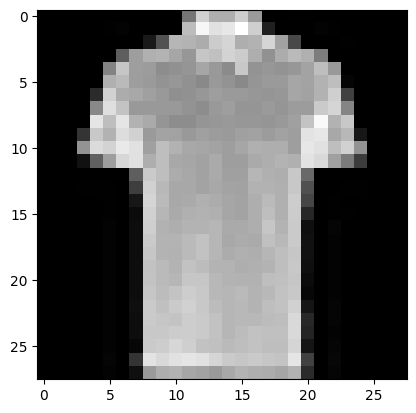

Label: 0


In [ ]:
train_features, train_labels = next(iter(train_dataloader)) # 데이터로더에서 배치 하나를 가져옴
print(f"Feature batch shape: {train_features.size()}") 
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze() # 배치에서 첫 번째 이미지 선택
label = train_labels[0] # 배치에서 첫 번째 레이블 선택
plt.imshow(img, cmap="gray") # 이미지 표시
plt.show() 
print(f"Label: {label}") 